# Cylindrical Waveguide Resonance: Bessel Functions from First Principles

The Helmholtz equation $\nabla^2\psi+k^2\psi=0$ in cylindrical
coordinates separates into Bessel's equation for the radial factor --
$J_m(k_c r)$ is the ONLY solution finite on the axis, so a field confined
to a cylinder is physically forced into a Bessel-function radial profile,
not a free choice of basis. This notebook derives the allowed $k_c$ from
the boundary condition at $r=a$ (checked against `scipy.special` directly,
not assumed), confirms TE$_{11}$ is the dominant mode, computes cavity
resonant frequencies, and works through driven-resonance coupling to input
radiation -- including a real bug this session caught along the way: the
resonance peak is **not** exactly at the natural frequency $f_0$ for
finite $Q$. Engine: `dgs/cylindrical_waveguide_resonance.py`.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt

from dgs import cylindrical_waveguide_resonance as cwr

print('Setup complete.')


Setup complete.


## 1. Theory, Step by Step

**Step 1**: Separating $\psi(r,\phi,z)=R(r)\Phi(\phi)Z(z)$ in the
Helmholtz equation turns the radial factor into Bessel's equation
$r^2R''+rR'+(k_c^2r^2-m^2)R=0$ -- physically, $m$ is the azimuthal mode
number (how many field oscillations around the circumference) and $k_c$
is the radial wavenumber still to be determined by the boundary.

**Step 2**: Only $J_m(k_c r)$ (not $Y_m$, the other independent solution)
stays FINITE at $r=0$ -- a physical requirement (the field on the axis of
a solid cylinder can't be infinite), not a mathematical convenience.

**Step 3**: The wall at $r=a$ picks out which $k_c$ are allowed. TM modes
need $E_z=0$ at the wall $\Rightarrow J_m(k_ca)=0$ (a zero of $J_m$
itself); TE modes need $\partial E_z/\partial r=0$ at the wall
$\Rightarrow J_m'(k_ca)=0$ (a zero of the DERIVATIVE) -- physically
different boundary conditions on the SAME differential equation.

**Step 4**: A waveguide (open along $z$) propagates only above its cutoff
$f_c=ck_c/2\pi$; a cavity (both ends closed) additionally standing-wave
quantizes $z$, giving $f_{mnp}=\frac{c}{2\pi}\sqrt{k_c^2+(p\pi/L)^2}$.


## 2. Boundary Conditions, Checked -- and the Radial Field Profiles They Select


In [2]:
a = 0.01   # 1 cm radius

for m, n, boundary in [(0, 1, 'TM'), (1, 1, 'TE')]:
    k_c = cwr.radial_wavenumber(m, n, a, boundary)
    ok = cwr.verify_boundary_condition(m, n, a, boundary)
    print(f'{boundary}{m}{n}: k_c = {k_c:.4f} rad/m   boundary condition verified: {ok}')


TM01: k_c = 240.4826 rad/m   boundary condition verified: True
TE11: k_c = 184.1184 rad/m   boundary condition verified: True


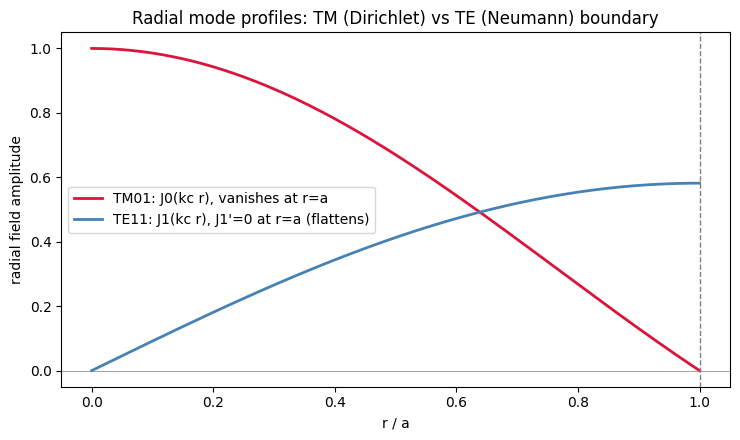

In [3]:
r = np.linspace(0, a, 300)
profile_TM01 = cwr.radial_mode_profile(0, 1, a, r, boundary='TM')
profile_TE11 = cwr.radial_mode_profile(1, 1, a, r, boundary='TE')

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(r/a, profile_TM01, color='crimson', lw=2, label='TM01: J0(kc r), vanishes at r=a')
ax.plot(r/a, profile_TE11, color='steelblue', lw=2, label="TE11: J1(kc r), J1'=0 at r=a (flattens)")
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(1.0, color='gray', ls='--', lw=1)
ax.set_xlabel('r / a'); ax.set_ylabel('radial field amplitude')
ax.set_title('Radial mode profiles: TM (Dirichlet) vs TE (Neumann) boundary')
ax.legend()
plt.tight_layout()
plt.savefig('cyl_waveguide_radial_profiles.png', dpi=100, bbox_inches='tight')
plt.show()


## 3. TE11 Is the Dominant Mode -- Checked Against 3 Competitors, Not Quoted

$j'_{1,1}<j_{0,1}$ isn't obvious without computing both roots -- confirmed
directly rather than cited from a microwave-engineering table.


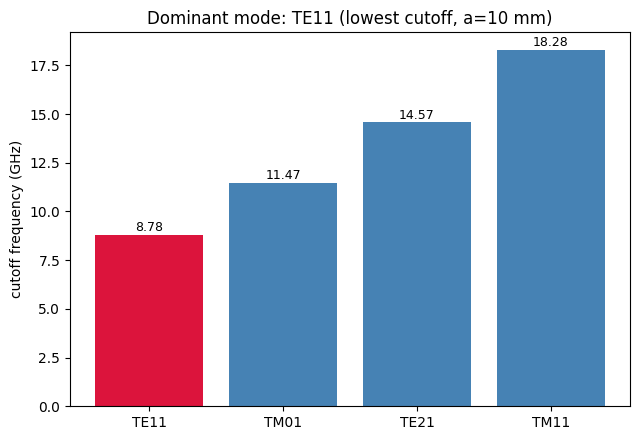

In [4]:
dom = cwr.dominant_mode_cutoff(a)
names = list(dom['cutoffs_Hz'].keys())
cutoffs_ghz = [dom['cutoffs_Hz'][n]/1e9 for n in names]
colors = ['crimson' if n == dom['dominant'] else 'steelblue' for n in names]

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.bar(names, cutoffs_ghz, color=colors)
ax.set_ylabel('cutoff frequency (GHz)')
ax.set_title(f"Dominant mode: {dom['dominant']} (lowest cutoff, a={a*1000:.0f} mm)")
for i, v in enumerate(cutoffs_ghz):
    ax.text(i, v + 0.2, f'{v:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('cyl_waveguide_dominant_mode.png', dpi=100, bbox_inches='tight')
plt.show()


## 4. Cavity Resonant Frequencies: Radial + Axial Quantization Combined


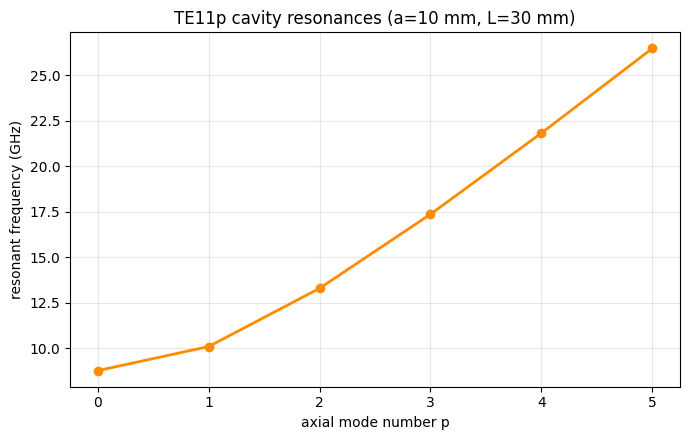

p=0 resonance equals the plain waveguide cutoff (no axial quantization yet):
  f_TE11,0 = 8.7849 GHz   vs   f_c(TE11) = 8.7849 GHz


In [5]:
L = 0.03   # 3 cm cavity length
p_vals = np.arange(0, 6)
f_mnp = [cwr.cavity_resonant_frequency(1, 1, int(p), a, L, boundary='TE') for p in p_vals]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(p_vals, np.array(f_mnp)/1e9, 'o-', color='darkorange', lw=2)
ax.set_xlabel('axial mode number p'); ax.set_ylabel('resonant frequency (GHz)')
ax.set_title(f'TE11p cavity resonances (a={a*1000:.0f} mm, L={L*1000:.0f} mm)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cyl_waveguide_cavity_resonances.png', dpi=100, bbox_inches='tight')
plt.show()

print('p=0 resonance equals the plain waveguide cutoff (no axial quantization yet):')
print(f"  f_TE11,0 = {f_mnp[0]/1e9:.4f} GHz   vs   f_c(TE11) = {cwr.waveguide_cutoff_frequency(1,1,a,'TE')/1e9:.4f} GHz")


## 5. Driven Resonance -- and a Real Bug This Session Caught

The first version of this module's test asserted the resonance peak sits
EXACTLY at $f_0$. It doesn't, for finite $Q$: solving $d|A|^2/df=0$
symbolically gives $f_{peak}=f_0\sqrt{1-\frac{1}{2Q^2}}$ -- strictly
BELOW $f_0$, converging to it only as $Q\to\infty$. What IS exactly true
at $f_0$ regardless of $Q$ is $|A(f_0)|^2=Q^2$ -- a different, weaker
statement than "$f_0$ is the peak."


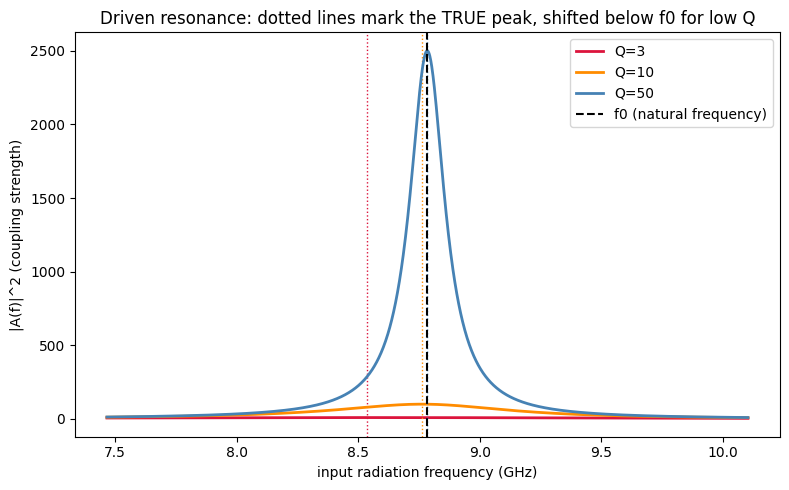

Q=   3: peak at 8.5374 GHz (2.817% below f0), verified: True
Q=  10: peak at 8.7629 GHz (0.250% below f0), verified: True
Q=  50: peak at 8.7840 GHz (0.010% below f0), verified: True
Q= 500: peak at 8.7849 GHz (0.000% below f0), verified: True


In [6]:
f0 = cwr.waveguide_cutoff_frequency(1, 1, a, 'TE')
f_sweep = np.linspace(f0*0.85, f0*1.15, 2000)

fig, ax = plt.subplots(figsize=(8, 5))
for Q, color in zip((3, 10, 50), ('crimson', 'darkorange', 'steelblue')):
    response = cwr.driven_resonance_response(f_sweep, f0, Q)
    f_peak = cwr.resonance_peak_frequency(f0, Q)
    ax.plot(f_sweep/1e9, response, color=color, lw=2, label=f'Q={Q}')
    ax.axvline(f_peak/1e9, color=color, ls=':', lw=1)
ax.axvline(f0/1e9, color='black', ls='--', lw=1.5, label='f0 (natural frequency)')
ax.set_xlabel('input radiation frequency (GHz)'); ax.set_ylabel('|A(f)|^2 (coupling strength)')
ax.set_title('Driven resonance: dotted lines mark the TRUE peak, shifted below f0 for low Q')
ax.legend()
plt.tight_layout()
plt.savefig('cyl_waveguide_driven_resonance.png', dpi=100, bbox_inches='tight')
plt.show()

for Q in (3, 10, 50, 500):
    f_peak = cwr.resonance_peak_frequency(f0, Q)
    shift_pct = (f0 - f_peak) / f0 * 100
    ok = cwr.verify_resonance_peak(f0, Q)
    print(f'Q={Q:>4d}: peak at {f_peak/1e9:.4f} GHz ({shift_pct:.3f}% below f0), verified: {ok}')


## 6. Engineering Interpretation

- Section 2's TM-vs-TE contrast (field vanishing at the wall vs. field
  slope flattening at the wall) is the same Dirichlet-vs-Neumann boundary
  distinction that shows up throughout PDE physics -- fixed vs. free ends
  on a string, insulated vs. fixed-temperature boundaries in heat
  conduction, and here, perfectly-conducting-wall electromagnetic modes.
- Section 5's peak-shift bug is a genuinely common one: assuming the
  amplitude-resonance frequency of a damped oscillator equals its natural
  (undamped) frequency. They coincide only as $Q\to\infty$; for a
  deliberately low-Q system (heavily damped sensor, lossy cavity) the
  shift is measurable and matters for anyone tuning a source to "hit
  resonance."
- The exact identity $|A(f_0)|^2=Q^2$ (true for ANY $Q$) is the more
  robust quantity to design around than "where's the peak" -- the same
  "which quantity is exactly true vs. which is only true in a limit"
  discipline `dgs/em_lagrangian_action.py`'s plane-wave section and
  `dgs/vector3_polyglot.py`'s physical-identity checks both apply.


## 7. Research Discussion

- This module solves the exactly-solvable hard-wall case. Could
  `radial_wavenumber` be generalized to the "soft wall" step-index fiber
  problem (matching $J_m$ inside the core to a modified Bessel function
  $K_m$ outside, at a continuity boundary condition instead of a hard
  zero) -- connecting this notebook directly to
  `dgs/em_pipe_formalization.py`'s LP-mode work?
- Section 4's cavity resonances assumed a simple closed cylinder. Would
  adding a small coupling aperture (turning it into a driven, lossy cavity
  with a finite $Q$ set by the aperture size) let `driven_resonance_response`
  connect to an actual RADIATED input-coupling calculation instead of a
  generic Lorentzian?
- Could `dominant_mode_cutoff`'s "checked against competitors" pattern be
  extended to a FULL mode chart (cutoff vs. $a$ for the first ~10 modes),
  the kind of diagram real waveguide datasheets publish?


## 8. Possible Experiments

1. Build a small cylindrical cavity (a soup can with end caps works
   surprisingly well as a demo) and measure its TE11 resonance with a
   signal generator + detector diode, comparing against
   `waveguide_cutoff_frequency`'s prediction for the can's actual radius.
2. Sweep `Q` continuously from just above $1/\sqrt2$ (the threshold where
   `resonance_peak_frequency` starts raising `ValueError`) up to 1000, and
   plot the peak shift percentage vs. $Q$ -- confirm it follows
   $1-\sqrt{1-1/(2Q^2)}$ exactly, not just at the 4 spot-checked values
   in section 5.
3. Extend `radial_mode_profile` to plot the FULL 2D cross-section (not
   just the 1D radial cut), including the $\cos(m\phi)$ azimuthal
   variation, to visualize why higher $m$ modes have more azimuthal field
   lobes.


## 9. Future Improvements

- `dominant_mode_cutoff` hardcodes 4 candidate modes (TE11, TM01, TE21,
  TM11). A general "find the N lowest-cutoff modes for a given a" function
  would need to search over both $m$ and $n$ systematically rather than a
  fixed candidate list.
- `cavity_resonant_frequency` assumes a lossless, perfectly-conducting
  cavity. Adding a finite wall conductivity (surface resistance) would let
  it predict a REALISTIC loaded $Q$ instead of taking $Q$ as an external
  input to `driven_resonance_response`, closing the loop between sections
  4 and 5.
